### Helper for Coursework V2

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import os
from typing import TypedDict, List, Any
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

d:\LangGraph\langgraph_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Input

In [3]:
from langchain_core.callbacks import StdOutCallbackHandler
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Initialize models
llm = ChatOpenAI(model="gpt-5-mini", temperature=0.2, callbacks=[StdOutCallbackHandler()],streaming=True, verbose=True)
embedding_tool = OpenAIEmbeddings(model="text-embedding-3-large")

PDF of subjects

In [4]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader, PyPDFLoader
#from langchain_community.document_loaders.csv_loader import CSVLoader

dir_loader = DirectoryLoader(
    "../Data/pdf",
    glob="Ma_Siu_Lun,_Ng_Kah_Loon,_Victor_Tan_Linear_Algebra_Concepts_and.pdf",
    loader_cls=PyPDFLoader,
    show_progress=True
)
document = dir_loader.load()


100%|██████████| 1/1 [00:03<00:00,  3.16s/it]


Syllabus

In [10]:
syl_loader = DirectoryLoader(
    "../Data/pdf",
    glob="MSSCourseDescription.pdf",
    loader_cls=PyPDFLoader,
    show_progress=False
)
syllabus = syl_loader.load()

Chunking for data

In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_documents(documents, chunk_size=500, chunk_overlap=50):
    """ Split documents into smaller chunks
    Args:
        documents: List of Document objects or raw strings.
        chunk_size: Max characters per chunk.
        chunk_overlap: Overlap between chunks.
    Returns:
        List of Document chunks
    """
    # ✅ Ensure all inputs are Document objects
    if isinstance(documents[0], str):
        documents = [Document(page_content=doc, metadata={}) for doc in documents]

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=['\n\n', '\n', ' ', '']
    )
    
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    
    # show example of chunk
    if split_docs:
        print(f"\n Example chunk")
        print(f"Content : {split_docs[0].page_content[:200]}...")
        print(f"Metadata : {split_docs[0].metadata}")
    
    return split_docs


data_chunks = split_documents(document, chunk_size=50, chunk_overlap=10)

Split 246 documents into 9025 chunks

 Example chunk
Content : LINEAR ALGEBRA...
Metadata : {'producer': 'pikepdf 4.3.1', 'creator': 'ocrmypdf 13.2.0 / Tesseract OCR-PDF 4.1.1', 'creationdate': '2021-08-05T14:17:12+00:00', 'author': '', 'moddate': '2022-01-08T20:19:31+00:00', 'source': '..\\Data\\pdf\\Ma_Siu_Lun,_Ng_Kah_Loon,_Victor_Tan_Linear_Algebra_Concepts_and.pdf', 'total_pages': 246, 'page': 0, 'page_label': 'i'}


Chunking for syllabus/course outline

In [12]:
syl_chunks = split_documents(syllabus, chunk_size=20, chunk_overlap=5)

Split 4 documents into 575 chunks

 Example chunk
Content : Restricted...
Metadata : {'producer': 'MiKTeX pdfTeX-1.40.24', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-01-24T12:01:13+08:00', 'author': '', 'title': '', 'subject': '', 'keywords': '', 'moddate': '2025-01-24T12:01:13+08:00', 'trapped': '/False', 'ptex.fullbanner': 'This is MiKTeX-pdfTeX 4.10.0 (1.40.24)', 'source': '..\\Data\\pdf\\MSSCourseDescription.pdf', 'total_pages': 4, 'page': 0, 'page_label': '1'}


Embedding

In [13]:
def batch_iter(items, batch_size):
    for i in range(0, len(items), batch_size):
        yield items[i:i + batch_size]

# Extract text from chunks
data_texts = [doc.page_content for doc in data_chunks]
syl_texts = [doc.page_content for doc in syl_chunks]

data_embeddings = []
syl_embeddings = []

for batch in batch_iter(data_texts, batch_size=200):  
    batch_embeds = embedding_tool.embed_documents(batch)
    data_embeddings.extend(batch_embeds)

for batch in batch_iter(syl_texts, batch_size=50):  
    batch_embeds = embedding_tool.embed_documents(batch)
    syl_embeddings.extend(batch_embeds)

Store into vectorDB

In [14]:
text_embed_pairs = [
    (doc.page_content, emb)
    for doc, emb in zip(data_chunks, data_embeddings)
]
data_vectorstore = FAISS.from_embeddings(text_embed_pairs, embedding_tool)
data_retriever = data_vectorstore.as_retriever(k=5)

syl_embed_pairs = [
    (doc.page_content, emb)
    for doc, emb in zip(syl_chunks, syl_embeddings)
]
syl_vectorestore = FAISS.from_embeddings(syl_embed_pairs, embedding_tool)
syl_retriever = syl_vectorestore.as_retriever(k=3)

### Agent State

In [ ]:
from langchain_core.messages import BaseMessage
class AgentState(TypedDict):
    messages: List[BaseMessage]
    question: str
    rewritten_prompt: str
    document: List[Any]
    #reranked_docs: List[Any]
    critique: str
    confidence: float
    revision_number: int
    max_revisions: int
    needs_retrieval: bool
    draft_answer: str
    tool_iterations: int
    max_tool_iterations: int


In [5]:
import time
from functools import wraps

def timed_node(name: str):
    def decorator(fn):
        @wraps(fn)
        def wrapper(state):
            start = time.perf_counter()
            result = fn(state)
            elapsed = time.perf_counter() - start
            print(f"[TIMING] {name}: {elapsed:.3f}s")
            return result
        return wrapper
    return decorator


### Agents

1. Query Rewriting Agent

In [12]:
from langchain_core.prompts import PromptTemplate

def rewrite_query(state: AgentState) -> AgentState:
    """
    Rewrite the query for better efficiency
    """
    query = state["question"]
    hyde_prompt = f"""
        You are an academic assistant specializing in university-level STEM subjects.
        Rewrite the student's question as a detailed, neutral, textbook-style paragraph
        that could appear in lecture notes or a reference book.

        Rules:
        - Do NOT answer the question directly.
        - Do NOT provide conclusions or final results.
        - Do NOT use conversational language.
        - Write in an explanatory, formal, educational tone.
        - Include relevant technical terms and concepts that would help retrieval.
        - The paragraph should look like background material that contains the answer.

        Student question:
        {query}

        Hypothetical textbook paragraph:
    """
    hyde_template = PromptTemplate.from_template(hyde_prompt)
    prompt = hyde_template.format(query=query)
    result = llm.invoke(prompt)
    print("Rewritting query...\n")
    print(f"Rewritten prompt:\n{result.content}\n")
    return {"rewritten_prompt": result.content}



2. Syllabus Checker

In [13]:
COURSE_TOPICS = """
TABLE OF CONTENTS

Chapter 1: Linear Systems and Gaussian Elimination (Page 1)
  Section 1.1: Linear Systems and Their Solutions (Page 1)
  Section 1.2: Elementary Row Operations (Page 6)
  Section 1.3: Row-Echelon Forms (Page 8)
  Section 1.4: Gaussian Elimination (Page 11)
  Section 1.5: Homogeneous Linear Systems (Page 22)
  Exercise 1 (Page 24)

Chapter 2: Matrices (Page 33)
  Section 2.1: Introduction to Matrices (Page 33)
  Section 2.2: Matrix Operations (Page 36)
  Section 2.3: Inverses of Square Matrices (Page 45)
  Section 2.4: Elementary Matrices (Page 48)
  Section 2.5: Determinants (Page 59)
  Exercise 2 (Page 70)

Chapter 3: Vector Spaces (Page 84)
  Section 3.1: Euclidean n-Spaces (Page 84)
  Section 3.2: Linear Combinations and Linear Spans (Page 89)
  Section 3.3: Subspaces (Page 98)
  Section 3.4: Linear Independence (Page 102)
  Section 3.5: Bases (Page 106)
  Section 3.6: Dimensions (Page 111)
  Section 3.7: Transition Matrices (Page 116)
  Exercise 3 (Page 120)

Chapter 4: Vector Spaces Associated with Matrices (Page 130)
  Section 4.1: Row Spaces and Column Spaces (Page 130)
  Section 4.2: Ranks (Page 139)
  Section 4.3: Nullspaces and Nullities (Page 141)
  Exercise 4 (Page 145)

Chapter 5: Orthogonality (Page 150)
  Section 5.1: The Dot Product (Page 150)
  Section 5.2: Orthogonal and Orthonormal Bases (Page 153)
  Section 5.3: Best Approximations (Page 160)
  Section 5.4: Orthogonal Matrices (Page 165)
  Exercise 5 (Page 170)

Chapter 6: Diagonalization (Page 178)
  Section 6.1: Eigenvalues and Eigenvectors (Page 178)
  Section 6.2: Diagonalization (Page 185)
  Section 6.3: Orthogonal Diagonalization (Page 192)
  Section 6.4: Quadratic Forms and Conic Sections (Page 196)
  Exercise 6 (Page 202)

Chapter 7: Linear Transformations (Page 210)
  Section 7.1: Linear Transformations from R^n to R^m (Page 210)
  Section 7.2: Ranges and Kernels (Page 215)
  Section 7.3: Geometric Linear Transformations (Page 219)
  Exercise 7 (Page 230)"""

In [ ]:
def check_query(state: AgentState) -> AgentState:
    """
    LLM decides whether the question is within course scope.
    """

    question = state["question"]

    prompt = f"""
                You are deciding whether a student's question should be answered
                using course materials.

                Course topics:
                {COURSE_TOPICS}

                Student question:
                {question}

                Rules:
                - Answer IN_SCOPE only if the question clearly requires knowledge
                from one or more course topics.
                - Answer OUT_OF_SCOPE if it relies mainly on general physics,
                chemistry, biology, or unrelated mathematics.
                - If unsure, answer OUT_OF_SCOPE.

                Return exactly:
                Decision: IN_SCOPE or OUT_OF_SCOPE
                Relevant topics: <comma-separated list or NONE>
            """

    output = llm.invoke(prompt).content.strip()

    in_scope = "IN_SCOPE" in output
    if in_scope:
        needs_retrieval = True
    else:
        needs_retrieval = False
    
    return {"needs_retrieval": needs_retrieval}

3. Retriever

In [15]:
def retrieve_documents(state: AgentState, threshold=0.3) -> AgentState:
    """
    Retrieve relevant documents based on the question
    """
    query = state["rewritten_prompt"]
    data_result = data_vectorstore.similarity_search_with_score(query, k=100)
    data_result = [(doc, float(score)) for doc, score in data_result]
    print("Retrieving data...\n")
    filtered_data = [(doc, score) for doc, score in data_result if score >= threshold]
    if filtered_data:
        return {"document": filtered_data}
    else:
        return {"document": data_result[0], "needs_retrieval": False}
    


4. Re-ranker

In [16]:
import re
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("BAAI/bge-reranker-large")

def rerank_documents(state: AgentState) -> AgentState:
    query = state["rewritten_prompt"]
    retrieved_docs = state["document"]

    if not retrieved_docs:
        return {"reranked_docs": []}

    # keep top 25% but at least 1
    k = max(1, int(len(retrieved_docs) * 0.25))

    print("Re-ranking with BGE cross encoder...\n")

    # Build (query, document) pairs
    pairs = [(query, doc.page_content) for doc, _ in retrieved_docs]

    # CrossEncoder returns float scores directly
    scores = reranker.predict(pairs)

    # Combine docs with scores
    scored = [(doc, float(score)) for (doc, _), score in zip(retrieved_docs, scores)]

    # Sort by relevance
    scored.sort(key=lambda x: x[1], reverse=True)

    final_docs = scored[:k]
    print(f"{final_docs[0]}\n")
    return {"reranked_docs": final_docs}

    #return {"reranked_docs": retrieve_documents}


5. Drafting Agent

In [17]:
def build_context(reranked_docs, max_chars=4000):
    context_parts = []
    total = 0

    for i, (doc, score) in enumerate(reranked_docs):
        text = doc.page_content.strip()

        #include at least one chunk
        if i == 0 and len(text) > max_chars:
            context_parts.append(text[:max_chars])
            break

        if total + len(text) > max_chars:
            break

        context_parts.append(text)
        total += len(text)

    return "\n\n---\n\n".join(context_parts)

def drafting_agent(state: AgentState) -> AgentState:
    question = state["question"]
    reranked_docs = state["reranked_docs"]
    previous_draft = state.get("draft_answer", None)
    critique = state.get("critique", None)

    context = build_context(reranked_docs)

    # Decide whether this is first draft or revision
    if previous_draft is None:
        draft_prompt = f"""
            You are a university teaching assistant. Answer the student's question using
            ONLY the information provided in the context below.

            Rules:
            - Do not introduce information not in the context.
            - If the context is insufficient, say so clearly.
            - Use clear explanations suitable for students.
            - Keep the answer concise but accurate.

            Student question:
            {question}

            Context:
            {context}

            Draft answer:
        """
    else:
        # Revision draft
        draft_prompt = f"""
            You are a university teaching assistant revising a previous answer.

            Important:
            - The previous draft MAY contain information from outside the context.
            - You must treat the context as the ONLY source of truth.
            - If any part of the previous draft contradicts or exceeds the context, remove or correct it.
            - Do not preserve any claim that is not supported by the context.

            Student question:
            {question}

            Previous draft (may contain inaccuracies or information not in the context):
            {previous_draft}

            Professor's critique:
            {critique}

            Context (authoritative source):
            {context}

            Revise the draft so that:
            - All critique points are addressed.
            - The answer is clearer and more precise.
            - The answer remains grounded ONLY in the context.

            Revised draft answer:
        """
    revision_num = state.get("revision_number", 0)
    print(f"Drafting answer number {revision_num}...\n")
    draft = llm.invoke(draft_prompt).content
    
    print(f"LLM Draft {revision_num}:\n{draft}\n")

    return {
        "draft_answer": draft,
    }


    

In [18]:
def fallback_agent(state: AgentState) -> AgentState:
    prompt = f"""
        You are a helpful university assistant.

        The student's question is outside the scope of the course materials,
        so answer using general knowledge. Be clear, concise, and honest.

        Student question:
        {state["question"]}

        Answer:
    """
    answer = llm.invoke(prompt).content
    print("Generating answer without retrieval...\n")
    print(f"Drafted answer:\n{answer}\n")
    return {
        "draft_answer": answer,
        "revision_number": 0
    }


6. Critique Agent

In [19]:
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
def critique_agent(state: AgentState) -> AgentState:
    """
    Takes in the answer from the drafting agent and critiques the accuracy of it.
    Takes into account whether the answer lacks depth or clarity and outputs a statement for improvements
    """
    answer = state["draft_answer"]
    question = state["question"]

    system_msg = SystemMessage(content="""
        You are a university professor specializing in STEM subjects.
        Your job is to critically evaluate student-facing answers for correctness,
        clarity, depth, and academic rigor. Be strict and objective.
        Do not rewrite the answer. Only critique it.
    """)

    human_msg = HumanMessage(content=f"""
        Evaluate the following draft answer based on:

        - Clarity of explanation
        - Specificity and completeness
        - Whether it addresses the question
        - Accuracy of technical details
        - Areas that need further explanation or correction

        Student's question:
        {question}

        Draft answer:
        {answer}

        Write a concise but thorough critique:
    """)
    print("Critiquing the answer...\n")
    critique = llm.invoke([system_msg, human_msg]).content
    print(f"Critique agent's critique:\n{critique}\n")
    return {"critique": critique}

7. Improving Agent

In [7]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(api_key=os.getenv("TAVILY_API_KEY"), max_results=5)

llm_with_tools = llm.bind_tools([web_search])


d:\LangGraph\langgraph_env\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
d:\LangGraph\langgraph_env\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


In [8]:
def improving_agent(state: AgentState) -> AgentState:

    tool_iterations = state.get("tool_iterations", 0)

    if tool_iterations >= state["max_tool_iterations"]:
        # Stop tool usage, force final answer
        system = SystemMessage(content="Finalize the improved answer now. Do not use any tools.")
        human = HumanMessage(content=f"""
            Student question:
            {state["question"]}

            Current draft answer:
            {state["draft_answer"]}

            Critique:
            {state["critique"]}

            Write the improved answer now.
        """)
        response = llm.invoke([system, human])
        print(f"Last iteration:\n{response}\n")
        return {"messages": state.get("messages", []) + [response]}

    system = SystemMessage(content="""
        You are an academic research assistant.
        Your job is to improve a draft answer based on a professor’s critique.
        You may call tools (like web search) if factual information is missing or uncertain.
    """)

    human = HumanMessage(content=f"""
        Student question:
        {state["question"]}

        Current draft answer:
        {state["draft_answer"]}

        Critique:
        {state["critique"]}

        Improve the draft. Use web search if necessary.
        Return ONLY the improved draft answer.
    """)

    response = llm_with_tools.invoke([system, human])
    print("Improving answer...\n")
    print(f"Iteration draft:\n{response}\n")

    return {
        "messages": state.get("messages", []) + [response],
        "tool_iterations": state.get("tool_iterations", 0) + (1 if hasattr(response, "tool_calls") and response.tool_calls else 0)
    }

In [9]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode([web_search])

8. Finalize

In [23]:
def finalize_improvement(state: AgentState) -> AgentState:
    """
    Takes the last LLM message and stores it as the improved draft answer.
    """
    last_msg = state["messages"][-1]

    improved = last_msg.content

    revision_num = state.get("revision_number", 0) + 1
    
    return {
        "draft_answer": improved,
        "messages": [],  # clear messages buffer for next loop
        "revision_number": revision_num
    }


9. Confidence Agent

In [24]:
def confidence_agent(state: AgentState) -> AgentState:
    question = state["question"]
    answer = state["draft_answer"]
    evidence = state.get("reranked_docs", []) or []

    # No retrieval
    if len(evidence) == 0:
        prompt = f"""
            You are an academic evaluator.

            Given a student's question and an answer produced WITHOUT access to course context,
            rate your confidence that the answer is correct based on general knowledge.

            Rules:
            - Return a 1 decimal point number between 0 and 10.
            - If the question is specific and out-of-scope of course content, lower the confidence.
            - If the answer contains uncertain claims, lower the confidence.

            Question:
            {question}

            Answer:
            {answer}

            Confidence score (0–10):
        """
        output = llm.invoke(prompt).content.strip()
        matches = re.findall(r"[-+]?\d*\.\d+|\d+", output)
        score = float(matches[0]) if matches else 0.0
        score = max(0.0, min(round(score, 1), 10.0))
        print(f"Confidence score with no retrieval: {score}")
        return {"confidence": score}

    # RAG
    context = build_context(evidence)

    confidence_prompt = f"""
        You are an academic evaluator.

        Given:
        - The student's question
        - The final answer
        - The supporting context

        Rate how confident you are that the answer is:
        1) Correct
        2) Fully supported by the context
        3) Free from hallucination

        Return a 1 decimal point number between 0 and 10.

        Question:
        {question}

        Answer:
        {answer}

        Context:
        {context}

        Confidence score (0–10):
    """
    output = llm.invoke(confidence_prompt).content.strip()
    matches = re.findall(r"[-+]?\d*\.\d+|\d+", output)
    score = float(matches[0]) if matches else 0.0
    score = max(0.0, min(round(score, 1), 10.0))
    print(f"Confidence score with retrieval: {score}\n")

    return {"confidence": score}


10. Output

In [25]:
def output_node(state: AgentState):
    print("Final Answer:\n")
    print(f"{state["draft_answer"]}\n")
    print(f"Number of drafts: {state["revision_number"]}\n")
    
    return {
        "answer": state["draft_answer"],
        "confidence": state["confidence"]
    }


In [26]:
def should_retrieve(state: AgentState) -> str:
    """
    Determine the next step based on retrieval decision
    """
    if state["needs_retrieval"]:
        return "retriever"
    else:
        return "generate"
    
def should_continue_revision(state: AgentState):
    if state["revision_number"] < state["max_revisions"]:
        return "revise"
    return "done"


### Graph

In [27]:
from langgraph.prebuilt import tools_condition

workflow = StateGraph(AgentState)

#Nodes
workflow.add_node("query_rewritter", timed_node("query_rewritter")(rewrite_query))
workflow.add_node("check_query", timed_node("check_query")(check_query))
workflow.add_node("retriever", timed_node("retrieve_documents")(retrieve_documents))
workflow.add_node("reranker", timed_node("rerank_documents")(rerank_documents))
workflow.add_node("drafting_agent", timed_node("drafting_agent")(drafting_agent))
workflow.add_node("fallback", timed_node("fallback_agent")(fallback_agent))
workflow.add_node("critique_agent", timed_node("critique_agent")(critique_agent))
workflow.add_node("improving_agent", timed_node("improving_agent")(improving_agent))
workflow.add_node("final_improvement", timed_node("finalize_improvement")(finalize_improvement))
workflow.add_node("confidence_agent", timed_node("confidence_agent")(confidence_agent))
workflow.add_node("output", output_node)
workflow.add_node("tools", tool_node)


#Start point
workflow.set_entry_point("query_rewritter")

#Conditional
workflow.add_conditional_edges(
    "check_query",
    should_retrieve,
    {
        "retriever": "retriever",
        "generate": "fallback"  
    }
)
workflow.add_conditional_edges(
    "improving_agent",
    tools_condition,          # checks if last message contains tool calls
    {
        "tools": "tools",                    # go to ToolNode
        END: "final_improvement"           # go to finalising
    }
)
workflow.add_conditional_edges(
    "final_improvement",
    should_continue_revision,
    {
        "revise": "drafting_agent",
        "done": "confidence_agent"
    }
)



#Edges
workflow.add_edge("query_rewritter", "check_query")
workflow.add_edge("retriever", "reranker")
workflow.add_edge("reranker", "drafting_agent")
workflow.add_edge("drafting_agent", "critique_agent")
workflow.add_edge("fallback", "confidence_agent")         #When there is no retrieval
workflow.add_edge("critique_agent", "improving_agent")
workflow.add_edge("tools", "improving_agent")
workflow.add_edge("confidence_agent", "output")
workflow.add_edge("output", END)



In [28]:
graph = workflow.compile(checkpointer=memory)


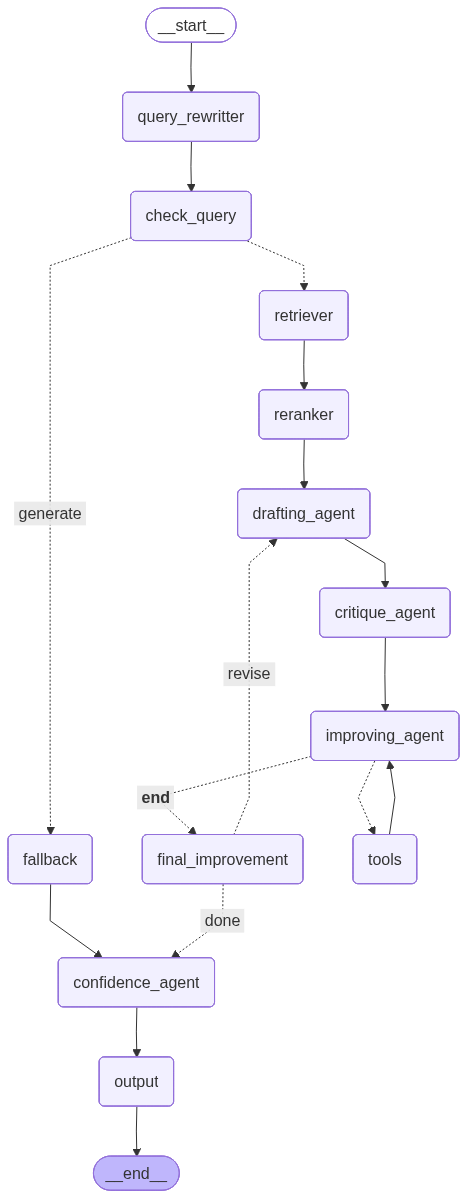

In [40]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
import uuid

thread_id = str(uuid.uuid4())

initial_state = {
        "messages": [],
        "question": "What is Hilbert space?",
        "rewritten_prompt":"",
        "needs_retrieval": True,
        "document": [],
        "reranked_docs": [],
        "critique": "",
        "confidence": 0.0,
        "revision_number": 0,
        "max_revisions": 1,
        "draft_answer": "",
        "tool_iterations": 0,
        "max_tool_iterations": 3,
    }

result = graph.invoke(
    initial_state,
    config={"configurable": {"thread_id": thread_id}, "callbacks": [StdOutCallbackHandler()]}
)





> Entering new LangGraph chain...


> Entering new query_rewritter chain...
Rewritting query...

Rewritten prompt:
A Hilbert space is the prototypical example of a complete inner product space: a vector space over the real or complex field equipped with an inner product ⟨·,·⟩ that induces a norm ∥x∥ = √⟨x,x⟩ and the corresponding metric, together with the requirement that every Cauchy sequence (with respect to this norm) converges to a limit in the space. Key structural features include orthogonality and orthonormal systems, the existence of orthogonal projections onto closed subspaces (projection theorem), and the availability of orthonormal bases in the sense of complete orthonormal systems (with Parseval’s identity and expansion of vectors as convergent series). Hilbert spaces are Banach spaces with additional inner-product structure, allowing polarization identities to recover the inner product from the norm and enabling the Riesz representation theorem, which identifies continuo